# AUto Encoder

In [68]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [69]:
data_path = Path("../outputs/results/creditcard_cleaned.pk1")

data = joblib.load(data_path)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (226980, 30)
X_test shape: (56746, 30)
y_train shape: (226980,)
y_test shape: (56746,)


In [70]:
X_train_normal = X_train[y_train == 0]

print("Normal training transactions:", X_train_normal.shape)

Normal training transactions: (226602, 30)


## Why Train Only on Normal Transactions?

- The Autoencoder is trained only on normal transactions so that it learns the structure of legitimate behaviour. 
- Fraudulent transactions are expected to produce higher reconstruction errors because the model has not learned those patterns during training.

In [71]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoder = Dense(24, activation="relu")(input_layer)
encoder = Dropout(0.2)(encoder)
encoder = Dense(12, activation="relu")(encoder)
bottleneck = Dense(6, activation="relu")(encoder)

decoder = Dense(12, activation="relu")(bottleneck)
decoder = Dropout(0.2)(decoder)
decoder = Dense(24, activation="relu")(decoder)
output_layer = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 24)             │           744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 12)             │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 24)             │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 30)             │           750 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268 (8.86 KB)

 Trainable params: 2,268 (8.86 KB)

 Non-trainable params: 0 (0.00 B)

## Autoencoder Architecture

The Autoencoder contains:

- An input layer matching the number of dataset features.
- Encoder layers that compress the transaction features.
- A bottleneck layer that stores a lower-dimensional representation.
- Decoder layers that reconstruct the original input.

Mean Squared Error is used as the loss function because the model is trained to minimize the difference between the original and reconstructed transaction.

In [72]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8043 - val_loss: 0.6292
Epoch 2/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6365 - val_loss: 0.5307
Epoch 3/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5862 - val_loss: 0.4867
Epoch 4/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5601 - val_loss: 0.4609
Epoch 5/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5466 - val_loss: 0.4413
Epoch 6/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5329 - val_loss: 0.4322
Epoch 7/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5254 - val_loss: 0.4258
Epoch 8/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5200 - val_loss: 0.4179
Epoch 9/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5142 - val_loss: 0.4103
Epoch 10/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5093 - val_loss: 0.4038
Epoch 11/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5047 - val_loss: 0.3949
Epoch 12/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

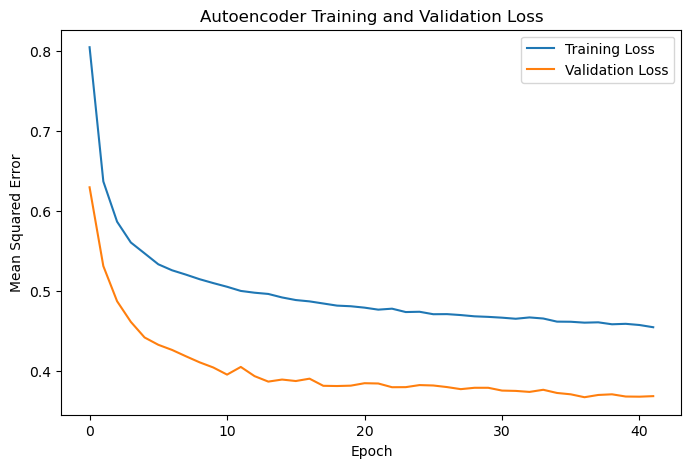

In [73]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

In [74]:
train_reconstructions = autoencoder.predict(X_train_normal)

train_loss = np.mean(
    np.square(X_train_normal.values - train_reconstructions),
    axis=1
)

train_loss[:10]

7082/7082 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


array([0.21967913, 0.29783704, 0.35985872, 0.45924444, 0.20718469,
       0.40455178, 0.18125015, 0.41128665, 0.10882363, 0.37866609])

In [75]:
threshold = np.percentile(train_loss, 95)

print("Reconstruction error threshold:", threshold)

Reconstruction error threshold: 0.8764382298916129


## Threshold Selection

- The anomaly threshold is selected using the 95th percentile of reconstruction error from normal training data.
- This means that transactions with reconstruction errors higher than most normal transactions are classified as anomalies. 
- The threshold can later be adjusted to study the trade-off between precision and recall.

In [76]:
test_reconstructions = autoencoder.predict(X_test)

test_loss = np.mean(
    np.square(X_test.values - test_reconstructions),
    axis=1
)

test_loss[:10]

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


array([0.11924841, 0.10527707, 0.82297302, 0.1856693 , 0.15307201,
       0.11135787, 0.31891571, 0.21881258, 0.44846377, 0.35617228])

In [77]:
y_pred = (test_loss > threshold).astype(int)

In [78]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56651
           1       0.03      0.84      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.90      0.51     56746
weighted avg       1.00      0.95      0.97     56746

Confusion Matrix:
[[53862  2789]
 [   15    80]]


In [79]:
autoencoder_results = {
    "Model": "Autoencoder",
    "Threshold": threshold,
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, test_loss),
    "PR-AUC": average_precision_score(y_test, test_loss)
}

autoencoder_results_df = pd.DataFrame([autoencoder_results])
autoencoder_results_df

,Model,Threshold,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Autoencoder,0.876438,0.027884,0.842105,0.053981,0.946092,0.345006


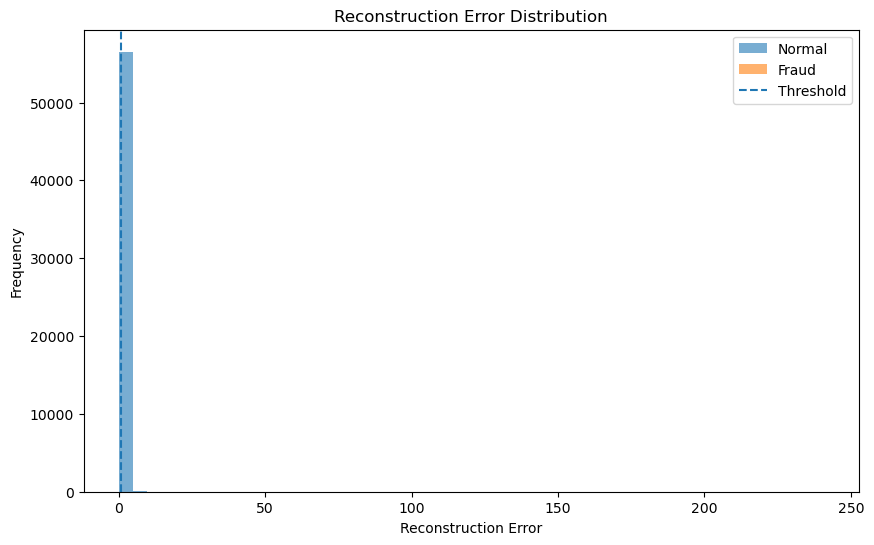

In [80]:
plt.figure(figsize=(10, 6))

plt.hist(test_loss[y_test == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(test_loss[y_test == 1], bins=50, alpha=0.6, label="Fraud")

plt.axvline(threshold, linestyle="--", label="Threshold")

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [81]:
threshold_percentiles = [90, 92, 95, 97, 99]

threshold_tuning_results = []

for percentile in threshold_percentiles:
    temp_threshold = np.percentile(train_loss, percentile)
    temp_pred = (test_loss > temp_threshold).astype(int)
    
    threshold_tuning_results.append({
        "Percentile": percentile,
        "Threshold": temp_threshold,
        "Precision": precision_score(y_test, temp_pred),
        "Recall": recall_score(y_test, temp_pred),
        "F1 Score": f1_score(y_test, temp_pred),
        "ROC-AUC": roc_auc_score(y_test, test_loss),
        "PR-AUC": average_precision_score(y_test, test_loss)
    })

autoencoder_threshold_df = pd.DataFrame(threshold_tuning_results)
autoencoder_threshold_df

,Percentile,Threshold,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,90,0.642173,0.014089,0.852632,0.027721,0.946092,0.345006
1,92,0.707256,0.017408,0.852632,0.034120,0.946092,0.345006
2,95,0.876438,0.027884,0.842105,0.053981,0.946092,0.345006
3,97,1.148761,0.045195,0.831579,0.085730,0.946092,0.345006
4,99,1.960536,0.110787,0.800000,0.194622,0.946092,0.345006


In [82]:
output_path = Path("../outputs/results")
output_path.mkdir(parents=True, exist_ok=True)

autoencoder_results_df.to_csv(
    output_path / "autoencoder_results.csv",
    index=False
)

autoencoder_threshold_df.to_csv(
    output_path / "autoencoder_threshold_tuning.csv",
    index=False
)

autoencoder.save(output_path / "autoencoder_model.keras")

print("Autoencoder model and results saved successfully.")

Autoencoder model and results saved successfully.


## Autoencoder Summary

- The Autoencoder was trained only on normal transactions to learn legitimate transaction behaviour. 
- Fraud detection was performed using reconstruction error.

- Transactions with reconstruction error above the selected threshold were classified as fraudulent.

- The threshold was initially set at the 95th percentile of normal training reconstruction errors.
-  Additional threshold tuning was performed to observe the trade-off between precision and recall.
This model provides an anomaly detection approach that complements supervised baseline models such as Logistic Regression, Random Forest, and Gradient Boosting, tested in notebooks 01-03